# Tutorial: Multi-Agent PDE Control with Neural Operators

Welcome to this interactive tutorial! In this notebook, we will explore how to stabilize complex, chaotic physical systems using a multi-agent framework powered by Neural Operators and Differentiable Physics. 

## 1. Problem Formulation

We consider the optimal control of a time-dependent physical state field, denoted as $z(x,t)$, evolving over a bounded spatial domain $\Omega \subset \mathbb{R}^d$ and a finite time horizon $t \in [0,T]$. 

The system is actuated by a swarm of $M$ agents. For each agent $i \in \{1, \dots, M\}$:
* $\xi_i(t) \in \Omega$ is the agent's spatial position.
* $u_i(t) \in \mathbb{R}$ is the localized control intensity it applies.
* $v_i(t) \in \mathbb{R}^d$ is the agent's velocity (for mobile actuators, $\dot{\xi}_i(t) = v_i(t)$).

The general control problem is framed as minimizing an expected cumulative cost subject to the governing Partial Differential Equation (PDE) dynamics:

$$\min \mathcal{J} = \mathbb{E} \left[ \int_0^T l(z(x,t), u^M(t), v^M(t)) dt \right]$$

$$\text{s.t.} \quad \frac{\partial z}{\partial t} = \mathcal{F}(z(x,t)) + \sum_{i=1}^M \mathcal{B}(x, u_i(t), \xi_i(t))$$

Here, $\mathcal{F}$ represents the intrinsic nonlinear PDE dynamics (like diffusion or advection), and $\mathcal{B}$ is the actuation map projecting the agents' scalar control inputs into the continuous spatial domain.

## 2. The Actuation Model

To map the discrete agents' actions onto the continuous PDE field, we model their spatial influence using a Gaussian kernel. The total forcing applied to the environment is the superposition of each agent's local contribution:

$$\mathcal{B}(x, u(t)) = \sum_{i=1}^M b(x, \xi_i(t)) u_i(t)$$

Where the spatial footprint of an individual agent is defined as:

$$b(x, \xi) = \frac{1}{(2\pi\sigma^2)^{d/2}} \exp\left(-\frac{||x - \xi||^2}{2\sigma^2}\right)$$

The parameter $\sigma$ dictates the physical width of the actuator's influence.

## 3. Our Focus: The 1D Kuramoto-Sivashinsky (KS) Equation

In this tutorial, we will focus on stabilizing spatiotemporal chaos. We will use the 1D Kuramoto-Sivashinsky (KS) equation, a canonical model for pattern formation, flame fronts, and negative diffusion. 

The controlled KS equation on a periodic domain $\Omega = [0, L]$ is given by:

$$\frac{\partial z}{\partial t} + z \frac{\partial z}{\partial x} + \frac{\partial^2 z}{\partial x^2} + \frac{\partial^4 z}{\partial x^4} = \sum_{i=1}^M u_i(t) b(x, \xi_i)$$

* **The Challenge:** The term $\frac{\partial^2 z}{\partial x^2}$ acts as negative diffusion (generating energy at large scales), while $\frac{\partial^4 z}{\partial x^4}$ provides dissipation at small scales. This competing dynamic creates highly chaotic behavior. The zero-state $z(x) = 0$ is a linearly unstable equilibrium.
* **The Setup:** We will deploy $M=80$ *static* agents ($\dot{\xi}_i = 0$) equidistantly spaced across the domain. Their goal is to suppress the intrinsic turbulence and drive the system back to the zero state.

## 4. The Learning Objective

To train our shared Neural Operator policy without expert labels, we backpropagate through a differentiable PDE solver. The policy learns to balance tracking performance (stabilizing the field) against the control effort expended:

$$\mathcal{L}_{total} = \lambda_{track} \int_\Omega (z(x,t) - z_{target}(x))^2 dx + \lambda_{effort} \frac{1}{M} \sum_{i=1}^M u_i(t)^2$$

For our stabilization task, the target state is the unstable equilibrium: $z_{target}(x) = 0$.

## 5. Building the Differentiable Solver

To train a neural operator via differentiable physics, we need a solver written entirely in a differentiable framework. We will use **JAX**. 

The Kuramoto-Sivashinsky equation is notoriously difficult to solve numerically due to the stiff 4th-order spatial derivative ($\frac{\partial^4 z}{\partial x^4}$). Standard finite difference methods require impractically small time steps to remain stable. Instead, we use a **Pseudo-Spectral Method**:
1.  **Linear Terms:** The spatial derivatives are computed in Fourier space, where they become simple algebraic multiplications (e.g., taking the second derivative becomes multiplying by $-k^2$). We step these forward using an implicitly stable Crank-Nicolson scheme.
2.  **Nonlinear Term:** The $z \frac{\partial z}{\partial x}$ term is computed in real space to avoid expensive convolutions, then transformed back to Fourier space.
3.  **Forcing Term:** The agents' Gaussian influences are computed in real space and added to the dynamics.

Let's write the core physics step and the forcing function.

In [15]:
import jax
import jax.numpy as jnp
from functools import partial
import matplotlib.pyplot as plt

def forcing_fn_1d(xi_fixed, u_intensities, N, L, sigma):
    """
    Calculates the 1D Gaussian influence of STATIC actuators.
    Handles periodic boundary conditions.
    """
    x_coords = jnp.linspace(0, L, N, endpoint=False)
    
    def single_actuator(pos, intensity):
        # Periodic distance for influence
        dist = jnp.abs(x_coords - pos)
        dist = jnp.minimum(dist, L - dist) # Wrap around edges
        return intensity * jnp.exp(-(dist**2) / (2 * sigma**2))
    
    # Vectorize across all actuators
    forcings = jax.vmap(single_actuator)(xi_fixed, u_intensities)
    return jnp.sum(forcings, axis=0)

def ks_spectral_step(u_hat, u_field, xi_fixed, u_control, k, L_linear, N, L, dt, sigma):
    """
    Semi-Implicit Crank-Nicolson Spectral Step for the KS equation.
    """
    # 1. Non-linear term (computed in real space)
    # z * z_x = 0.5 * d/dx (z^2)
    u_sq = u_field ** 2
    u_sq_hat = jnp.fft.rfft(u_sq)
    
    # Nonlinearity in Fourier space: -0.5 * i * k * FFT(z^2)
    nonlinear_term_hat = -0.5 * (1j * k) * u_sq_hat
    
    # 2. Forcing term (computed in real space)
    f_field = forcing_fn_1d(xi_fixed, u_control, N, L, sigma)
    f_hat = jnp.fft.rfft(f_field)

    # 3. Time Stepping (Crank-Nicolson for Linear, Explicit for Non-linear & Forcing)
    denom = 1.0 - (dt / 2.0) * L_linear
    numer = (1.0 + (dt / 2.0) * L_linear) * u_hat + dt * (nonlinear_term_hat + f_hat)
    
    u_hat_next = numer / denom
    
    # 4. Recover real space for the next iteration
    u_next = jnp.fft.irfft(u_hat_next)
    
    return u_hat_next, u_next

## 6. Generating Chaotic Initial Conditions

To ensure our policy learns to control fully developed spatiotemporal chaos, we cannot simply initialize the environment with basic sine waves or white noise. 

Instead, we use a "spin-up" phase. We start with small random Gaussian noise and evolve the system autonomously (with zero control input) for a long warmup period. This allows the high-frequency noise to dissipate and the true chaotic attractor of the KS equation to form.

In [16]:
def generate_random_noise(key, N_grid, L, scale=0.01):
    """Generates initial random noise with zero mean to prevent drift."""
    u = jax.random.normal(key, shape=(N_grid,)) * scale
    u = u - jnp.mean(u)
    return u

@partial(jax.jit, static_argnames=("N_grid", "L", "warmup_time", "dt"))
def evolve_to_attractor(key, N_grid, L, warmup_time=1000.0, dt=0.05):
    """Evolves random noise for 'warmup_time' to reach the chaotic attractor."""
    u_init = generate_random_noise(key, N_grid, L)
    u_hat = jnp.fft.rfft(u_init)
    
    # Pre-calculate spatial frequencies and linear operator
    dx = L / N_grid
    k = 2 * jnp.pi * jnp.fft.rfftfreq(N_grid, d=dx)
    L_linear = k**2 - k**4
    
    steps = int(warmup_time / dt)
    
    # Dummy inputs since there's no control during warmup
    xi_dummy = jnp.zeros(1) 
    u_control_dummy = jnp.zeros(1)

    def warmup_step(carry, _):
        u_hat_curr, u_curr = carry
        u_hat_next, u_next = ks_spectral_step(
            u_hat_curr, u_curr, xi_dummy, u_control_dummy,
            k=k, L_linear=L_linear, N=N_grid, L=L, dt=dt, sigma=1.0
        )
        return (u_hat_next, u_next), None

    # Fast loop compilation with lax.scan
    (u_hat_final, u_final), _ = jax.lax.scan(
        warmup_step,
        (u_hat, u_init),
        None,
        length=steps
    )
    
    return u_final

def get_batch_initial_conditions(key, batch_size, N_grid, L):
    """Generates a batch of fully developed chaotic states concurrently."""
    keys = jax.random.split(key, batch_size)
    batch_u = jax.vmap(evolve_to_attractor, in_axes=(0, None, None))(keys, N_grid, L)
    return batch_u

## 7. Visualizing the Chaotic Attractor

Let's test our generation logic. We will set the domain length $L = 500.0$. Because the domain is so large, the chaotic behavior will be highly complex with many interacting cellular structures. To maintain stability and capture the physics accurately, we will use a high spatial resolution of $N = 1024$.

Generating KS Chaotic Attractor samples (L=500.0)...


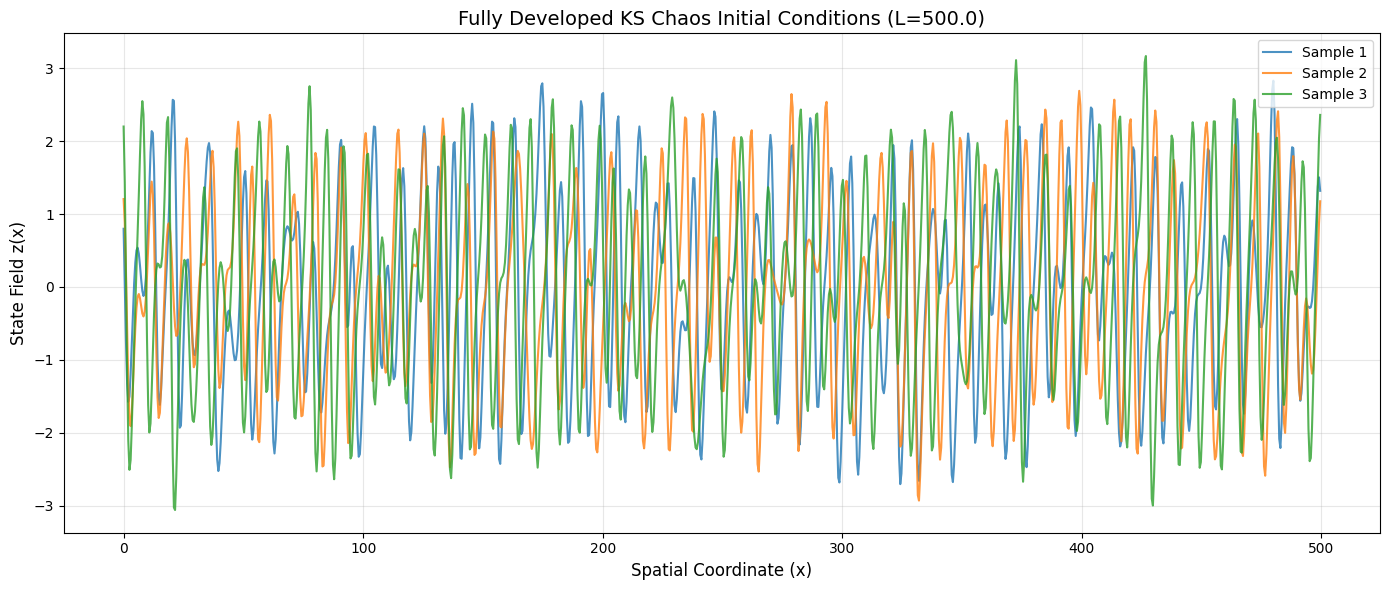

In [17]:
# --- Configuration ---
L_domain = 500.0
N_grid = 1024
batch_size = 3

print(f"Generating KS Chaotic Attractor samples (L={L_domain})...")
key = jax.random.PRNGKey(42)

# Generate 3 independent chaotic states
# (This will trigger JIT compilation on the first run)
u_samples = get_batch_initial_conditions(key, batch_size=batch_size, N_grid=N_grid, L=L_domain)

# Plotting
x_grid = jnp.linspace(0, L_domain, N_grid, endpoint=False)

plt.figure(figsize=(14, 6))
for i, u in enumerate(u_samples):
    plt.plot(x_grid, u, label=f"Sample {i+1}", alpha=0.8, linewidth=1.5)
    
plt.title(f"Fully Developed KS Chaos Initial Conditions (L={L_domain})", fontsize=14)
plt.xlabel("Spatial Coordinate (x)", fontsize=12)
plt.ylabel("State Field z(x)", fontsize=12)
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 8. The Neural Operator Policy

We've established the physics and the data generation. Now we construct the brain of our agents: the **Neural Operator Policy**. 

To achieve **cardinality invariance** (the ability to train on $M$ agents and deploy on $M'$ agents without retraining), we formulate the control problem as learning a mapping from an infinite-dimensional state space to a continuous control space. We parameterize this mapping using a Deep Operator Network (DeepONet) architecture.

### The DeepONet Architecture
A DeepONet consists of two parallel networks:
1.  **Branch Network:** Encodes the state function (the PDE field). In our decentralized setup, it processes a local patch of the PDE state field around the agent.
2.  **Trunk Network:** Encodes the query coordinate. Here, it processes the agent's spatial position $\xi_i$.

The outputs of the branch and trunk networks are combined (typically via dot product or concatenation followed by a small MLP) to produce the control action at that specific location.

### Decentralized Control with Periodic Boundaries
Because the KS equation operates on a periodic domain, our agents must be aware of the wrap-around topology. The `DecentralizedControlNet` handles this by extracting local observation windows using periodic padding. 

Let's look at the implementation using Flax.

In [18]:
import jax
import jax.numpy as jnp
from flax import linen as nn
from typing import Sequence

class DecentralizedControlNet(nn.Module):
    """
    Local Controller for KS with Periodic Boundaries.
    """
    features: Sequence[int]
    L_domain: float
    u_max: float = 1.0
    window_size: int = 4

    def setup(self):
        # Fourier features for the Trunk network (position encoding)
        self.frequencies = jnp.array([1.0, 2.0, 4.0, 8.0])

    def branch_net(self, local_patch):
        x = local_patch
        for feat in self.features:
            x = nn.Dense(feat)(x)
            # Simple normalization to keep gradients stable
            x = x / (jnp.linalg.norm(x) + 1.0) 
            x = nn.tanh(x)
        return x

    def trunk_net(self, xi_norm):
        angle = xi_norm[:, None] * self.frequencies * jnp.pi
        encoded = jnp.concatenate([jnp.sin(angle), jnp.cos(angle)], axis=-1)
        for feat in [32, 32]:
            encoded = nn.Dense(feat)(encoded)
            encoded = nn.tanh(encoded)
        return encoded 

    @nn.compact
    def __call__(self, u_curr, u_target, xi_fixed):
        xi_norm = xi_fixed / self.L_domain
        
        error = u_curr - u_target
        n_pde = u_curr.shape[0]
        
        # 1. Gradient
        error_grad = jnp.gradient(error)

        window_size = self.window_size 
        half_window = window_size // 2

        # 2. PAD with 'wrap' for PERIODIC BCs
        # This ensures agents at the domain edges 'see' their neighbors
        padded_error = jnp.pad(error, (half_window, half_window), mode='wrap')
        padded_grad = jnp.pad(error_grad, (half_window, half_window), mode='wrap')

        def get_local_obs(xi_n):
            # Map normalized position back to grid index
            center_idx = jax.lax.stop_gradient((xi_n * (n_pde - 1)).astype(int)) + half_window
            start = center_idx - half_window
            
            # Slice the periodic (wrapped) fields
            p_err = jax.lax.dynamic_slice(padded_error, (start,), (window_size,))
            p_grad = jax.lax.dynamic_slice(padded_grad, (start,), (window_size,))
            
            # Resize for a consistent input size (e.g., 20) regardless of window_size
            p_err = jax.image.resize(p_err, (20,), method='bilinear')
            p_grad = jax.image.resize(p_grad, (20,), method='bilinear')
            
            return jnp.concatenate([p_err, p_grad])

        # 3. Process each agent's view and position
        local_patches = jax.vmap(get_local_obs)(xi_norm)
        branch_outs = jax.vmap(self.branch_net)(local_patches)
        trunk_outs = self.trunk_net(xi_norm)

        # Combine Branch and Trunk outputs
        combined = jnp.concatenate([branch_outs, trunk_outs], axis=-1)
        x = nn.Dense(32)(combined)
        x = nn.tanh(x)
        
        # 4. Output Head (Control Intensity Only)
        u_raw = nn.Dense(1)(x).squeeze(-1)

        # Scale to max allowable intensity
        return self.u_max * jnp.tanh(u_raw)

## 9. Wrapping the Dynamics

Before writing the training loop, we need a wrapper class `PDEDynamics` that connects our policy network to the `ks_spectral_step` solver. This class handles the unrolling of the trajectory over time.

In [19]:
class PDEDynamics:
    def __init__(self, policy_apply_fn):
        self.policy_apply_fn = policy_apply_fn

    def unroll_controlled(
        self, u_init, xi_fixed, u_target, params, t_steps,
        N_grid, L, dt, sigma
    ):
        """
        Unrolls the controlled KS simulation over t_steps.
        """
        dx = L / N_grid
        k = 2 * jnp.pi * jnp.fft.rfftfreq(N_grid, d=dx)
        L_linear = k**2 - k**4
        
        u_hat_init = jnp.fft.rfft(u_init)

        def step_fn(carry, _):
            u_hat_curr, u_curr = carry
            
            # Policy determines control intensities
            u_control = self.policy_apply_fn(params, u_curr, u_target, xi_fixed)
            
            # Physics step
            u_hat_next, u_next = ks_spectral_step(
                u_hat_curr, u_curr, xi_fixed, u_control, 
                k, L_linear, N=N_grid, L=L, dt=dt, sigma=sigma
            )
            
            # For compatibility with generalized frameworks, we might return velocities.
            # Static actuators have 0 velocity.
            v_dummy = jnp.zeros_like(u_control) 
            
            return (u_hat_next, u_next), (u_next, xi_fixed, u_control, v_dummy)

        # Run the simulation loop
        _, trajectory = jax.lax.scan(
            step_fn, 
            (u_hat_init, u_init), 
            None, 
            length=t_steps
        )
        
        return trajectory

## 10. The Training Script

Now we bring it all together. We will:
1.  Initialize the model and optimizer.
2.  Define the loss function (Tracking MSE + Effort Penalty).
3.  Pre-generate a batch of chaotic initial conditions using the warmup function.
4.  Run the training loop, updating parameters using Backpropagation Through Time (BPTT).

NOTE: one can load the weights of a pretrained model by setting `LOAD_PRETRAINED_WEIGHTS = True` (defaults to `True`).

In [20]:
%pip install optax flax requests

import optax
import time
import os
import requests
import flax.serialization
from tqdm.auto import trange
from functools import partial
import jax
import jax.numpy as jnp

# --- 1. Configuration & Initialization ---

# ----- Config Toggle -----
LOAD_PRETRAINED_WEIGHTS = True  # Set to False to train from scratch

PARAMS_FILE = 'decentralized_params_ks1d.msgpack'
WEIGHTS_URL = "https://github.com/SOLARIS-JHU/CINOC/raw/main/tutorials/ks1d/decentralized_params_ks1d.msgpack"

# Setting parameters for the training run
N_grid = 1024      
L_domain = 500.0   # Larger domain length
n_agents = 200     # Fixed number of actuators
T_steps = 200      # Horizon for stabilization
batch_size = 64
epochs = 500

# Initialize Model
model = DecentralizedControlNet(features=(64, 64), L_domain=L_domain)
key = jax.random.PRNGKey(42)

key, init_key = jax.random.split(key)
dummy_u = jnp.zeros((N_grid,))
dummy_xi = jnp.linspace(0, L_domain, n_agents)
# Initialize parameters (we need this structure even if loading weights)
params = model.init(init_key, dummy_u, dummy_u, dummy_xi)

# Optimizer configuration
lr_schedule = optax.exponential_decay(1e-3, 500, 0.5)
optimizer = optax.chain(optax.clip_by_global_norm(1.0), optax.adam(lr_schedule))
opt_state = optimizer.init(params)

# --- 2. Loss Function ---
def loss_fn(params, u_init, xi_fixed, u_target, dynamics):
    # Unroll the dynamics
    u_traj, xi_traj, u_ctrl_traj, v_traj = dynamics.unroll_controlled(
        u_init, xi_fixed, u_target, params, T_steps, N_grid, L_domain, dt=0.05, sigma=1.0
    )
    
    # 1. Tracking Loss (Stabilize to zero)
    l_track = jnp.mean((u_traj - u_target[None, :]) ** 2)
    
    # 2. Effort Loss (Control Regularization)
    l_effort = jnp.mean(u_ctrl_traj ** 2) 

    # Weighted Sum - Strong emphasis on tracking due to chaotic nature
    total_loss = 10.0 * l_track + 0.001 * l_effort 
    
    return total_loss, (l_track, l_effort)

@partial(jax.jit, static_argnames='dynamics')
def train_step(params, opt_state, u_init_batch, xi_fixed_batch, u_target_batch, dynamics):
    # Vectorize the loss over the batch dimension
    batched_loss_fn = jax.vmap(loss_fn, in_axes=(None, 0, 0, 0, None))
    
    def mean_loss_fn(p):
        losses, auxs = batched_loss_fn(p, u_init_batch, xi_fixed_batch, u_target_batch, dynamics)
        return jnp.mean(losses), jax.tree_util.tree_map(jnp.mean, auxs)

    # Compute value and gradients
    (loss, aux), grads = jax.value_and_grad(mean_loss_fn, has_aux=True)(params)
    
    # Apply optimizer updates
    updates, opt_state = optimizer.update(grads, opt_state, params)
    params = optax.apply_updates(params, updates)
    return params, opt_state, loss, aux

# --- 3. Training Loop Setup ---
dynamics = PDEDynamics(policy_apply_fn=model.apply)

print("Generating Chaotic Initial Conditions (Spin-up)...")
pool_size = 128 # Smaller pool size for this example script to run faster
key, subkey = jax.random.split(key)
u_init_pool = get_batch_initial_conditions(subkey, pool_size, N_grid, L_domain)

u_target_pool = jnp.zeros_like(u_init_pool)

# Fixed Actuator Positions (Equispaced across the domain)
xi_fixed_single = jnp.linspace(0.0, L_domain, n_agents, endpoint=False) + (L_domain/n_agents)/2
xi_fixed_batch = jnp.tile(xi_fixed_single, (batch_size, 1))


# --- 4. Main Training Loop / Loading ---
metrics = []

if LOAD_PRETRAINED_WEIGHTS:
    # Check if file is missing, OR if it's a tiny LFS pointer file (< 1000 bytes)
    if not os.path.exists(PARAMS_FILE) or os.path.getsize(PARAMS_FILE) < 1000:
        print("Downloading pre-trained weights from repository...")
        response = requests.get(WEIGHTS_URL, allow_redirects=True)
        with open(PARAMS_FILE, 'wb') as f:
            f.write(response.content)
            
    print(f"Loading trained weights from '{PARAMS_FILE}'...")
    with open(PARAMS_FILE, 'rb') as f:
        serialized_bytes = f.read()
        
    # Map the loaded bytes onto our initialized parameters structure
    params = flax.serialization.from_bytes(params, serialized_bytes)
    print("Weights loaded successfully! Skipping training.")

else:
    start_time = time.time()
    print(f"Starting Training on KS-1D (L={L_domain}, Agents={n_agents})...")

    for epoch in trange(epochs):
        # Sample batch
        key, subkey = jax.random.split(key)
        idx = jax.random.randint(subkey, (batch_size,), 0, pool_size)
        u_init_b = u_init_pool[idx]
        u_target_b = u_target_pool[idx]

        # Perform a training step
        params, opt_state, loss, aux = train_step(
            params, opt_state, u_init_b, xi_fixed_batch, u_target_b, dynamics
        )
        
        if epoch % 10 == 0:
            metrics.append((epoch, loss, *aux))
            tqdm_desc = f"Loss: {loss:.4f} | Track: {aux[0]:.4f} | Effort: {aux[1]:.4f}"
            print(f"Epoch {epoch:03d} | {tqdm_desc}")

    print(f"Training finished in {time.time() - start_time:.2f}s.")
    
    # Save weights after training so they can be loaded next time
    with open(PARAMS_FILE, 'wb') as f:
        f.write(flax.serialization.to_bytes(params))
    print(f"Saved trained weights to {PARAMS_FILE}")

Note: you may need to restart the kernel to use updated packages.
Generating Chaotic Initial Conditions (Spin-up)...
Loading trained weights from 'decentralized_params_ks1d.msgpack'...
Weights loaded successfully! Skipping training.


## 11. Evaluating the Policy: Natural vs. Controlled Evolution

Now that we have our solver, our policy network, and our initial conditions, let's visualize how the system behaves. We will compare two scenarios side-by-side:
1. **Natural Evolution:** The chaotic system evolves completely autonomously without any intervention.
2. **Controlled Evolution:** Our neural operator policy actively controls the 8 agents to stabilize the domain.

We will evaluate this on our chosen domain size of $L=500.0$. We'll plot the spatiotemporal heatmaps to see the wave dynamics, and track the overall system energy to quantify the stabilization performance.

Running Natural Evolution...
Running Controlled Evolution...


/tmp/ipykernel_12128/2294664002.py:94: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 1, 0.92])


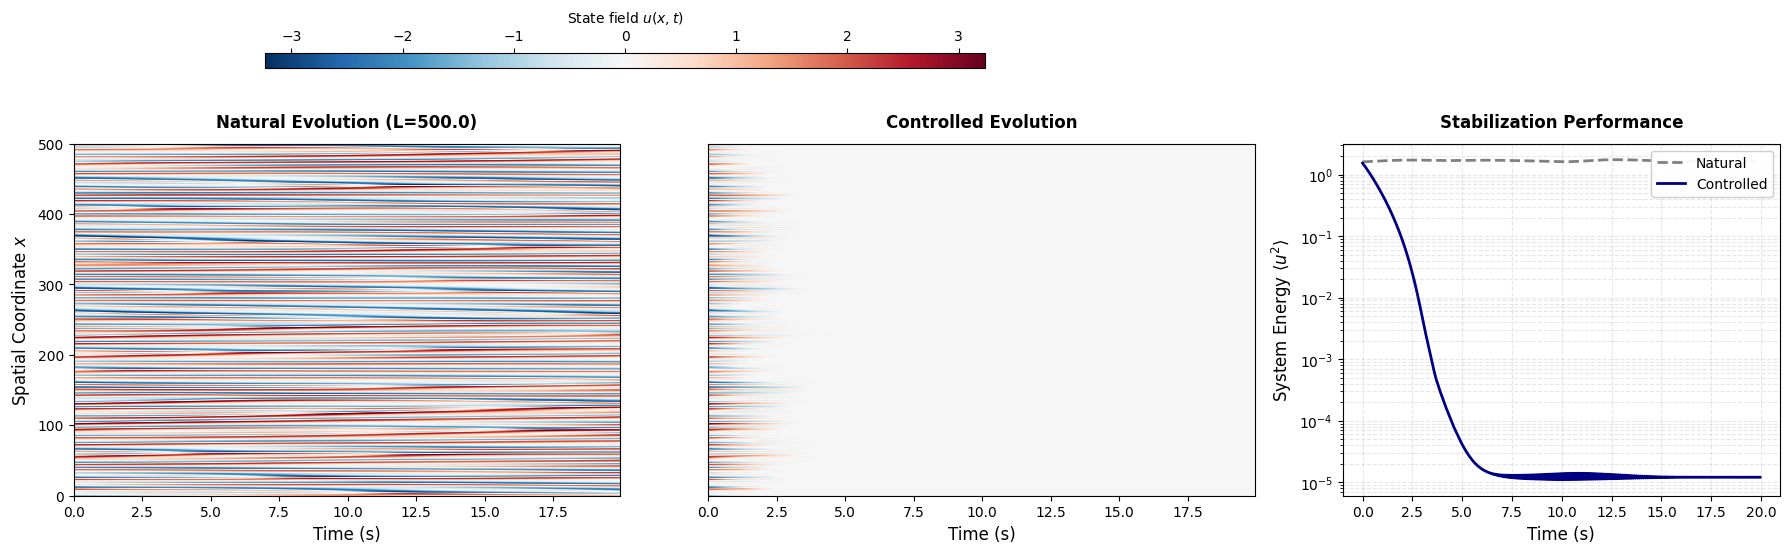

In [21]:
import numpy as np
import matplotlib.pyplot as plt

# --- 1. Setup Evaluation Parameters ---
L_eval = 500.0
N_eval = 1024
n_agents_eval = 200
t_steps_eval = 400
dt_eval = 0.05
sigma_eval = 1.0

def get_actuators(n_agents, L):
    """Returns fixed actuator positions distributed evenly across the domain."""
    return jnp.linspace(0.0, L, n_agents, endpoint=False) + (L/n_agents)/2

# --- 2. Initialize Models and States ---
# We use the parameters trained in the previous step (or initialized randomly if skipping training)
eval_model = DecentralizedControlNet(features=(64, 64), L_domain=L_eval)

# Define a "Zero Policy" for the natural evolution baseline
zero_policy_fn = lambda p, u, ut, xi: jnp.zeros(n_agents_eval)

dyn_control = PDEDynamics(policy_apply_fn=eval_model.apply)
dyn_natural = PDEDynamics(policy_apply_fn=zero_policy_fn)

xi_fixed_eval = get_actuators(n_agents_eval, L_eval)
u_target_eval = jnp.zeros(N_eval)

# Generate one chaotic initial condition
eval_key = jax.random.PRNGKey(123)
u0_eval = get_batch_initial_conditions(eval_key, 1, N_eval, L_eval)[0]

print("Running Natural Evolution...")
u_nat, _, _, _ = dyn_natural.unroll_controlled(
    u0_eval, xi_fixed_eval, u_target_eval, params,
    t_steps_eval, N_eval, L_eval, dt=dt_eval, sigma=sigma_eval
)

print("Running Controlled Evolution...")
u_ctrl, _, _, _ = dyn_control.unroll_controlled(
    u0_eval, xi_fixed_eval, u_target_eval, params,
    t_steps_eval, N_eval, L_eval, dt=dt_eval, sigma=sigma_eval
)

# --- 3. Visualization ---
t_axis = np.arange(t_steps_eval) * dt_eval

fig, axes = plt.subplots(1, 3, figsize=(18, 5), gridspec_kw={'width_ratios': [1, 1, 0.8]})

# Calculate color limits based on natural evolution
std_val = np.std(u_nat)
vmin, vmax = -2.5 * std_val, 2.5 * std_val

# Plot Natural Evolution
im0 = axes[0].imshow(u_nat.T, aspect='auto', origin='lower', cmap='RdBu_r',
                     extent=[t_axis[0], t_axis[-1], 0, L_eval],
                     vmin=vmin, vmax=vmax, interpolation='nearest')
axes[0].set_title(f"Natural Evolution (L={L_eval})", fontweight='bold', pad=12)
axes[0].set_xlabel("Time (s)", fontsize=12)
axes[0].set_ylabel(r"Spatial Coordinate $x$", fontsize=12)

# Plot Controlled Evolution
im1 = axes[1].imshow(u_ctrl.T, aspect='auto', origin='lower', cmap='RdBu_r',
                     extent=[t_axis[0], t_axis[-1], 0, L_eval],
                     vmin=vmin, vmax=vmax, interpolation='nearest')
axes[1].set_title("Controlled Evolution", fontweight='bold', pad=12)
axes[1].set_xlabel("Time (s)", fontsize=12)
axes[1].set_yticks([])

# # Add dashed lines for Actuator locations
# for pos in xi_fixed_eval:
#     axes[1].axhline(y=pos, color='black', linestyle='--', alpha=0.3)

# Plot Energy
e_nat = jnp.mean(u_nat**2, axis=1)
e_ctrl = jnp.mean(u_ctrl**2, axis=1)

axes[2].plot(t_axis, e_nat, color='grey', linestyle='--', lw=2.0, label='Natural')
axes[2].plot(t_axis, e_ctrl, color='navy', lw=2.0, label='Controlled')
axes[2].set_yscale('log')
axes[2].grid(True, which='both', linestyle='--', alpha=0.3)
axes[2].set_xlabel("Time (s)", fontsize=12)
axes[2].set_ylabel(r"System Energy $\langle u^2 \rangle$", fontsize=12)
axes[2].set_title("Stabilization Performance", fontweight='bold', pad=12)
axes[2].legend(loc='upper right', framealpha=0.95)

# Add a colorbar at the top
cbar_ax = fig.add_axes([0.15, 0.98, 0.4, 0.03]) 
cb = fig.colorbar(im0, cax=cbar_ax, orientation='horizontal')
cb.set_label(r'State field $u(x,t)$', rotation=0, labelpad=5)
cbar_ax.xaxis.set_label_position('top')
cbar_ax.xaxis.set_ticks_position('top')

plt.tight_layout(rect=[0, 0, 1, 0.92])
plt.show()